In [ ]:
import numpy as np

def convolve2d(image, kernel, stride=1, padding=0):

    image = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode='constant'
    )

    H, W = image.shape
    kH, kW = kernel.shape

    outH = (H - kH)//stride + 1
    outW = (W - kW)//stride + 1

    output = np.zeros((outH, outW))

    for i in range(outH):
        for j in range(outW):

            region = image[
                i*stride:i*stride+kH,
                j*stride:j*stride+kW
            ]

            output[i, j] = np.sum(region * kernel)

    return output


def max_pool2d(image, pool_size=2, stride=2):

    H, W = image.shape

    outH = (H - pool_size)//stride + 1
    outW = (W - pool_size)//stride + 1

    output = np.zeros((outH, outW))

    for i in range(outH):
        for j in range(outW):

            region = image[
                i*stride:i*stride+pool_size,
                j*stride:j*stride+pool_size
            ]

            output[i, j] = np.max(region)

    return output


def avg_pool2d(image, pool_size=2, stride=2):

    H, W = image.shape

    outH = (H - pool_size)//stride + 1
    outW = (W - pool_size)//stride + 1

    output = np.zeros((outH, outW))

    for i in range(outH):
        for j in range(outW):

            region = image[
                i*stride:i*stride+pool_size,
                j*stride:j*stride+pool_size
            ]

            output[i, j] = np.mean(region)

    return output

import numpy as np

img = np.array([
    [1,2,3],
    [4,5,6],
    [7,8,9]
])

kernel = np.array([
    [0,0,0],
    [0,1,0],
    [0,0,0]
])

result = convolve2d(img, kernel, padding=1)

print(result)


[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]


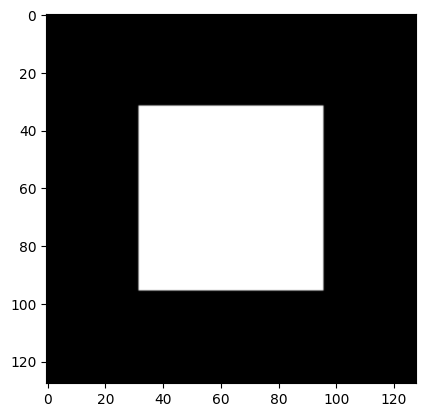

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
test_image = np.zeros((128,128))

test_image[32:96,32:96] = 1

plt.imshow(test_image,cmap='gray')
plt.show()


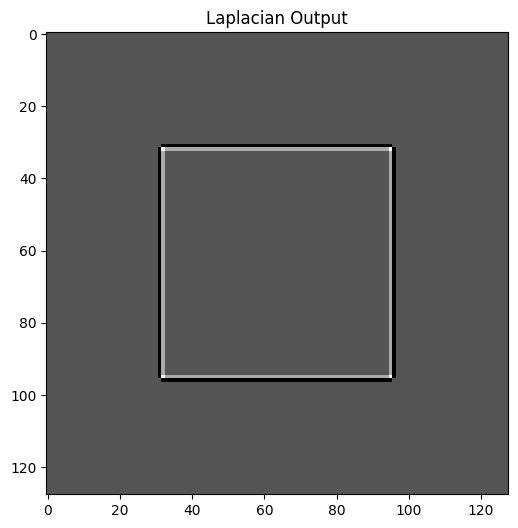

In [ ]:
laplacian = np.array([
    [0,-1,0],
    [-1,4,-1],
    [0,-1,0]
])

output = convolve2d(
    test_image,
    laplacian,
    stride=1,
    padding=1
)

plt.figure(figsize=(6,6))
plt.imshow(output,cmap='gray')
plt.title("Laplacian Output")
plt.show()

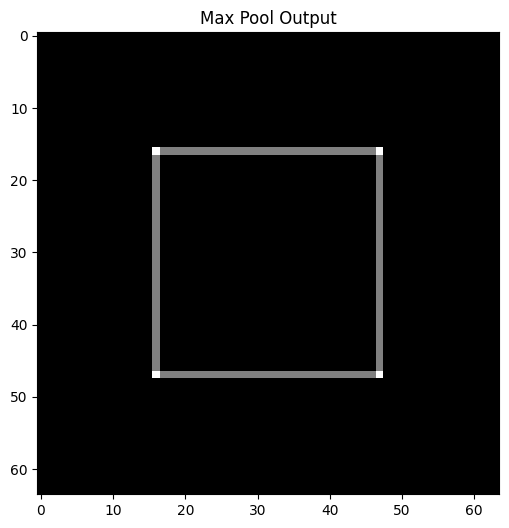

In [ ]:
pooled = max_pool2d(output, pool_size=2, stride=2)

plt.figure(figsize=(6,6))
plt.imshow(pooled, cmap='gray')
plt.title("Max Pool Output")
plt.show()


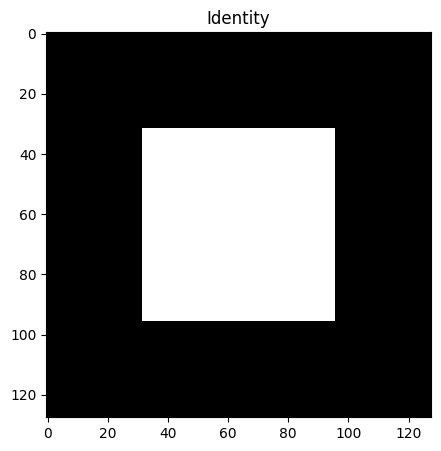

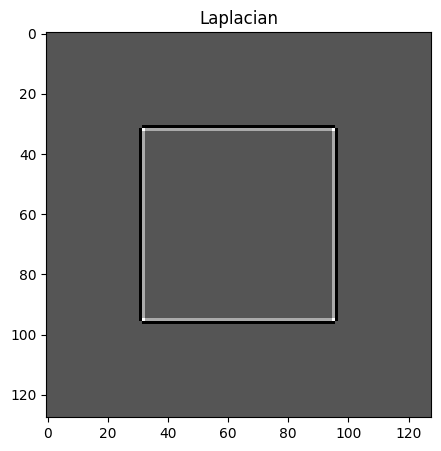

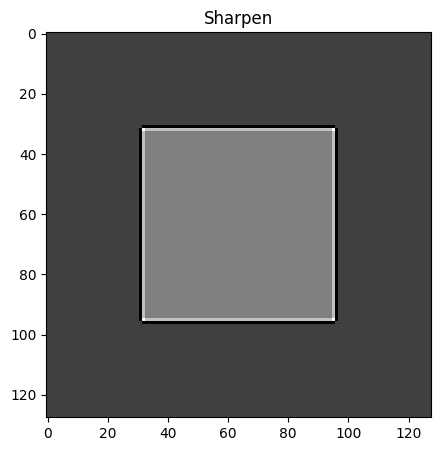

In [ ]:
kernels = {
    "Identity": np.array([[0,0,0],[0,1,0],[0,0,0]]),

    "Laplacian": np.array([[0,-1,0],
                           [-1,4,-1],
                           [0,-1,0]]),

    "Sharpen": np.array([[0,-1,0],
                         [-1,5,-1],
                         [0,-1,0]])
}

for name,kernel in kernels.items():

    conv = convolve2d(test_image,kernel,padding=1)

    plt.figure(figsize=(5,5))
    plt.imshow(conv,cmap='gray')
    plt.title(name)
    plt.show()